In [2]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [3]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install tqdm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [7]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import Sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.layers import Embedding, LSTM, add, Concatenate, Reshape
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import wrap
from nltk.translate.bleu_score import sentence_bleu
from nltk.tokenize import word_tokenize
import warnings
plt.rcParams['font.size'] = 12
sns.set_style("dark")
warnings.filterwarnings('ignore')

In [8]:
image_path = r"C:\Users\RAKHI ROSHAN\Downloads\flicker 8k\captions.txt"

In [9]:
data = pd.read_csv(r"C:\Users\RAKHI ROSHAN\Downloads\flicker 8k\captions.txt")
data.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [10]:
data['image'] = data['image'].apply(lambda x: x.split('#')[0])

In [11]:
print(data['image'].nunique())

8091


In [12]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

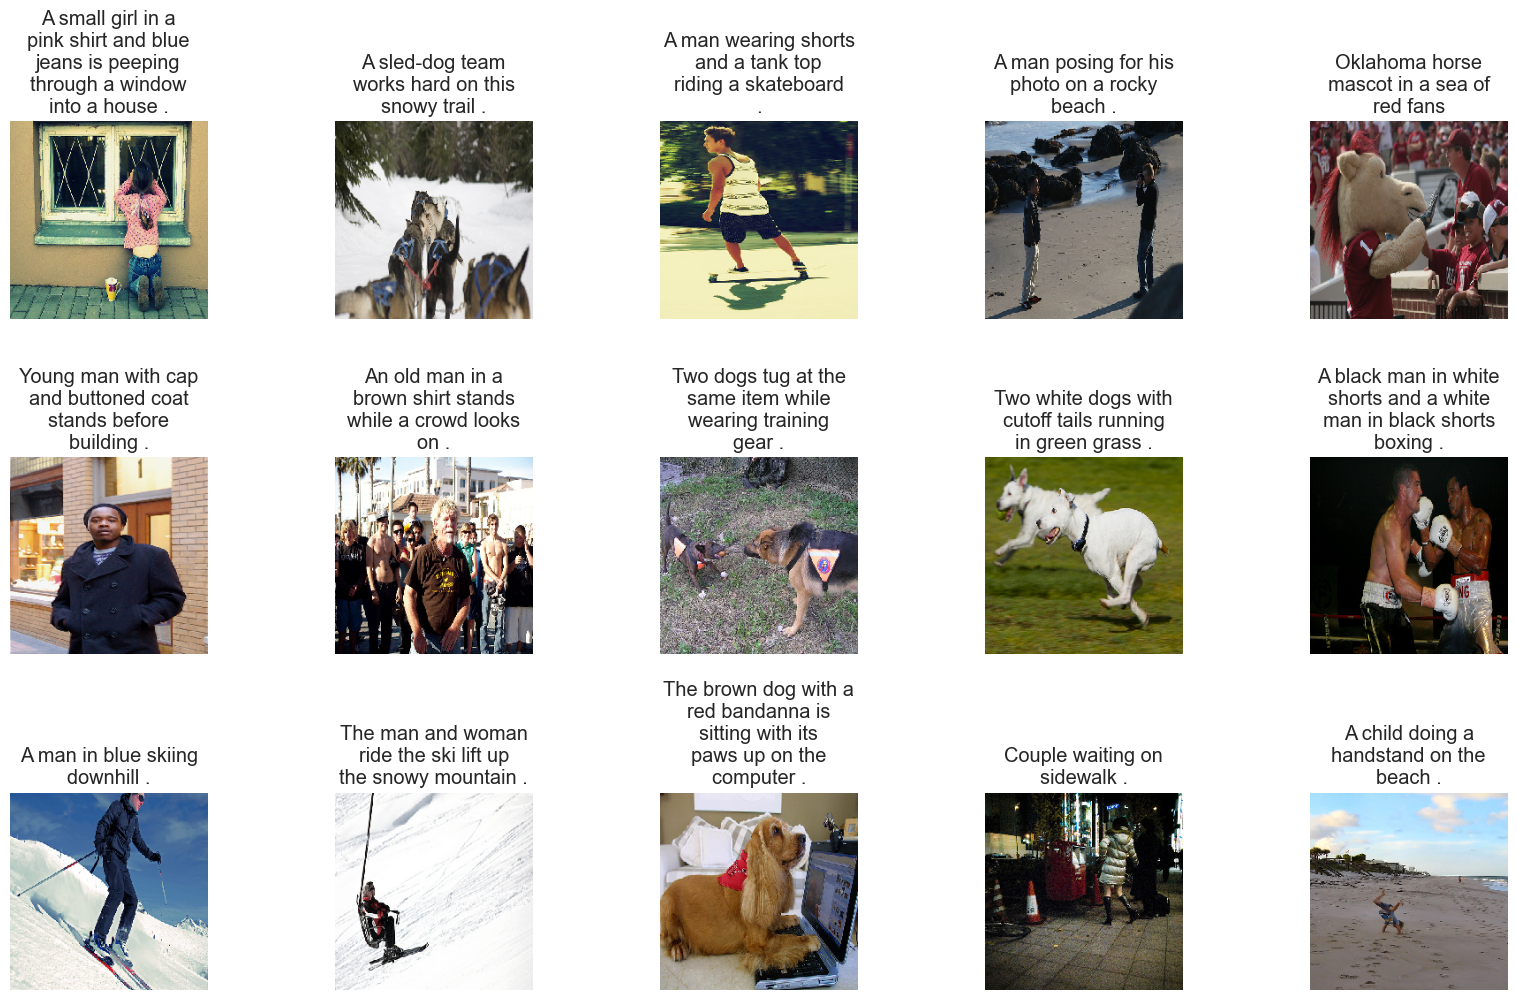

In [13]:
def readImage(path,img_size=224):
    img = load_img(path,color_mode='rgb',target_size=(img_size,img_size))
    img = img_to_array(img)
    img = img/255.0
    
    return img
    
def display_images(temp_df):
    temp_df = temp_df.reset_index(drop=True)
    plt.figure(figsize = (20 , 20))
    
    n = 0
    for i in range(15):
        n+=1
        plt.subplot(5 , 5, n)
        plt.subplots_adjust(hspace = 0.7, wspace = 0.3)

        img_path = os.path.join(
            r"C:\Users\RAKHI ROSHAN\Downloads\flicker 8k\Images",
            temp_df["image"][i]
        )

        image = readImage(img_path)
        
        plt.imshow(image)
        plt.title("\n".join(wrap(temp_df["caption"][i], 20)))
        plt.axis("off")
        
display_images(data.sample(15))

In [14]:
import re

def text_preprocessing(data):
    data['caption'] = data['caption'].apply(lambda x: x.lower())
    data['caption'] = data['caption'].apply(lambda x: re.sub("[^A-Za-z]", " ", x))
    data['caption'] = data['caption'].apply(lambda x: re.sub("\s+", " ", x))
    data['caption'] = data['caption'].apply(lambda x: " ".join([word for word in x.split() if len(word) > 1]))
    data['caption'] = "startseq " + data['caption'] + " endseq"
    return data

In [15]:
data = text_preprocessing(data)
captions = data['caption'].tolist()
captions[:10]

['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq',
 'startseq black dog and spotted dog are fighting endseq',
 'startseq black dog and tri colored dog playing with each other on the road endseq',
 'startseq black dog and white dog with brown spots are staring at each other in the street endseq',
 'startseq two dogs of different breeds looking at each other on the road endseq',
 'startseq two dogs on pavement moving toward each other endseq']

In [16]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(caption.split()) for caption in captions)
images = data['image'].unique().tolist()
nimages = len(images)
split_index = round(0.9*nimages)
train_images = images[:split_index]
val_images = images[split_index:]
train = data[data['image'].isin(train_images)]
test = data[data['image'].isin(val_images)]
train.reset_index(inplace=True,drop=True)
test.reset_index(inplace=True,drop=True)
tokenizer.texts_to_sequences([captions[1]])[0]

[1, 18, 313, 63, 194, 116, 2]

In [17]:
image_path = r"C:\Users\RAKHI ROSHAN\Downloads\flicker 8k\Images"

model = DenseNet201()
fe = Model(inputs=model.input, outputs=model.layers[-2].output)

img_size = 224
features = {}
for image in tqdm(data['image'].unique().tolist()):
    img = load_img(os.path.join(image_path,image),target_size=(img_size,img_size))
    img = img_to_array(img)
    img = img/255.
    img = np.expand_dims(img,axis=0)
    feature = fe.predict(img, verbose=0)
    features[image] = feature

100%|████████████████████████████████████████████████████████████████████████████| 8091/8091 [2:41:34<00:00,  1.20s/it]


In [18]:
print(len(features))

8091


In [9]:
from tensorflow.keras.utils import Sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np

In [9]:
from tensorflow.keras.utils import Sequence
import numpy as np


from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

class CustomDataGenerator(Sequence):

    def __init__(self, df, X_col, y_col, batch_size,
                 tokenizer, vocab_size, max_length):

        self.df = df
        self.X_col = X_col
        self.y_col = y_col
        self.batch_size = batch_size
        self.tokenizer = tokenizer
        self.vocab_size = vocab_size
        self.max_length = max_length

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def __getitem__(self, index):

        batch = self.df.iloc[
            index * self.batch_size:(index + 1) * self.batch_size
        ]

        X1, X2, y = [], [], []

        for _, row in batch.iterrows():

            image_feature = np.random.rand(1920)

            seq = self.tokenizer.texts_to_sequences(
                [row[self.y_col]]
            )[0]

            for i in range(1, len(seq)):

                in_seq = seq[:i]
                out_seq = seq[i]

                
                in_seq = pad_sequences(
                    [in_seq],
                    maxlen=self.max_length,
                    padding='post'
                )[0]

                out_seq = to_categorical(
                    out_seq,
                    num_classes=self.vocab_size
                )

                X1.append(image_feature)
                X2.append(in_seq)
                y.append(out_seq)

        return (np.array(X1), np.array(X2)), np.array(y)

In [10]:
import pandas as pd
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Reshape, add, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import add, concatenate

# load data
data = pd.read_csv('C:/Users/RAKHI ROSHAN\Downloads/flicker 8k/captions.txt')

In [11]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(data['caption'])

vocab_size = len(tokenizer.word_index) + 1

max_length = 34   
vocab_size = vocab_size 

# Model architecture (same as before)
input1 = Input(shape=(1920,))
input2 = Input(shape=(max_length,))

img_features = Dense(256, activation='relu')(input1)
img_features_reshaped = Reshape((1, 256))(img_features)

sentence_features = Embedding(vocab_size, 256, mask_zero=False)(input2)
merged = concatenate([img_features_reshaped, sentence_features], axis=1)
sentence_features = LSTM(256)(merged)
x = Dropout(0.5)(sentence_features)
x = add([x, img_features])
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(vocab_size, activation='softmax')(x)

caption_model = Model(inputs=[input1, input2], outputs=output)
caption_model.compile(loss='categorical_crossentropy', optimizer='adam')

In [12]:
import pydot
import graphviz
print("pydot & graphviz OK ✅")

pydot & graphviz OK ✅


In [13]:
from tensorflow.keras.utils import plot_model

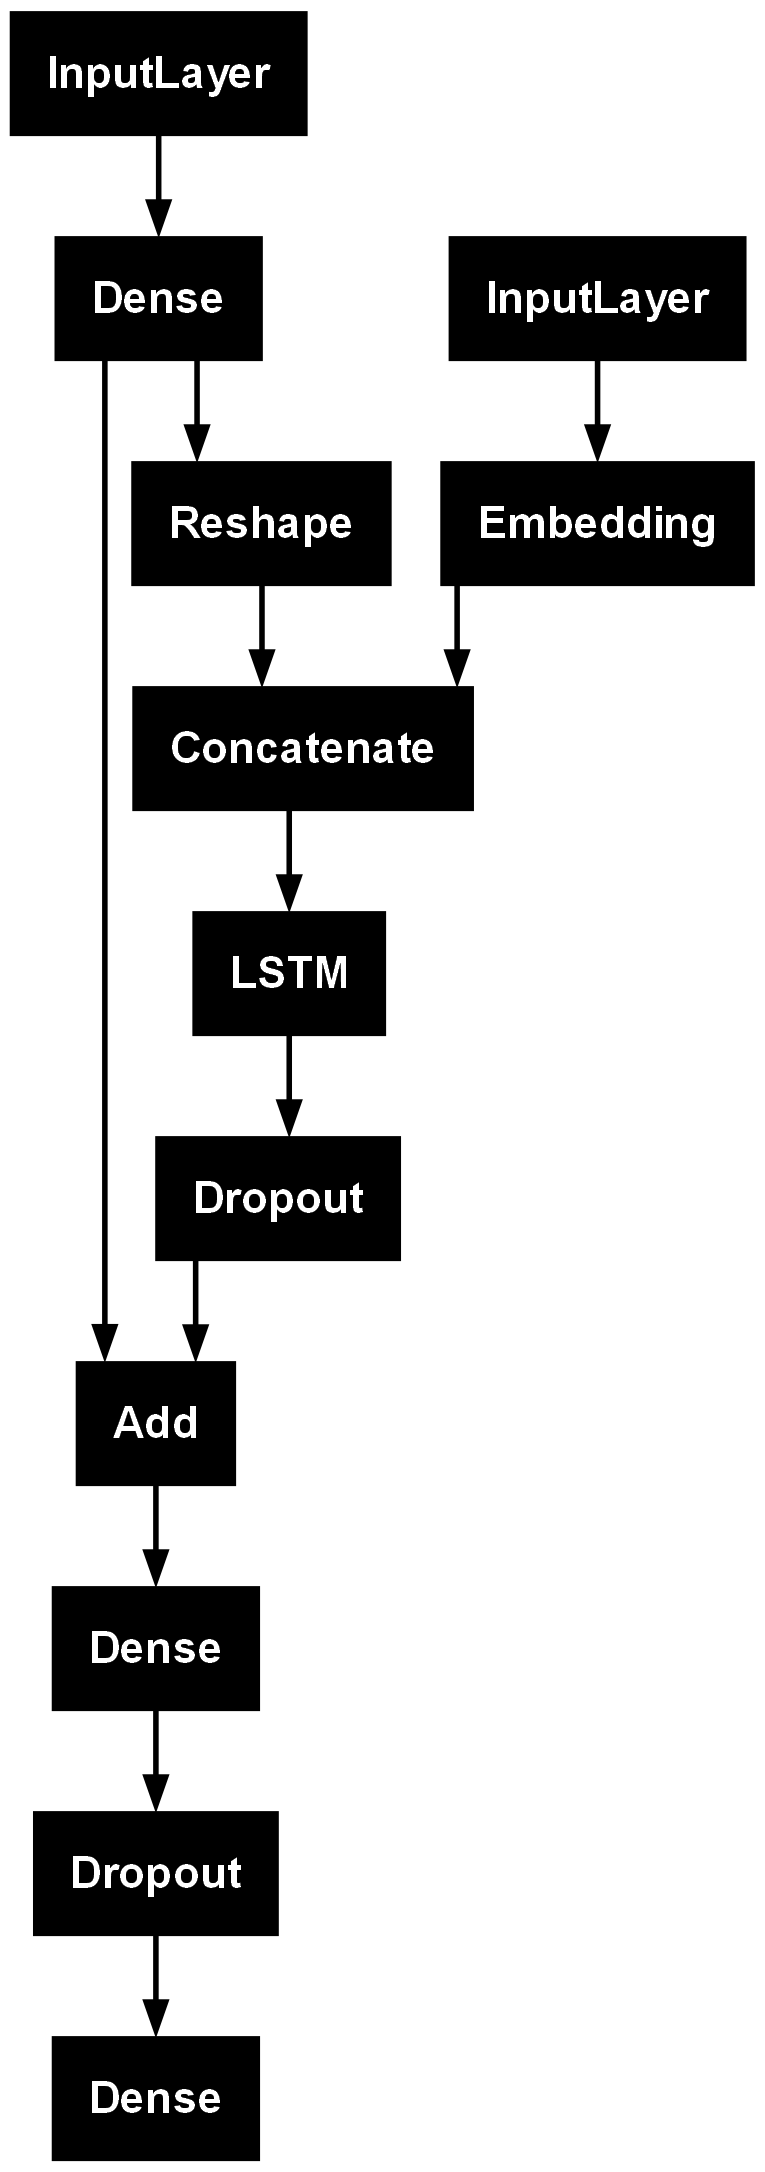

In [14]:
plot_model(caption_model)

In [15]:
caption_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 1920)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 256)               │         491,776 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 34)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 1, 256)            │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 34, 256)           │       2,174,464 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 35, 256)           │               0 │ reshape[0][0],             │
│                               │                           │                 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 256)               │         525,312 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 256)               │               0 │ lstm[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 256)               │               0 │ dropout[0][0], dense[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 128)               │          32,896 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 128)               │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 8494)              │       1,095,726 │ dropout_1[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 4,320,174 (16.48 MB)

 Trainable params: 4,320,174 (16.48 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.2, random_state=42)

In [17]:
features_dict = {}

features = features_dict

train_generator = CustomDataGenerator(df=train,X_col='image',y_col='caption',batch_size= 32,
tokenizer=tokenizer,vocab_size=vocab_size,max_length= max_length)
validation_generator = CustomDataGenerator(df=test,X_col='image',y_col='caption',batch_size= 32,
tokenizer=tokenizer,vocab_size=vocab_size,max_length=  max_length)

In [18]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Callbacks
model_name = "model.keras"
checkpoint = ModelCheckpoint(
    model_name,
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

earlystopping = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=5,
    verbose=1,
    restore_best_weights=True
)
learning_rate_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    verbose=1,
    factor=0.2,
    min_lr=0.00000001
)


In [19]:
# Train the model
history = caption_model.fit(
    train_generator,
    epochs=31,  
    steps_per_epoch=113,
    validation_data=validation_generator,
    validation_steps=113,
    callbacks=[
        checkpoint,
        learning_rate_reduction
    ],
    verbose=1
)

C:\Users\RAKHI ROSHAN\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/31
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - loss: 6.8490  
Epoch 1: val_loss improved from None to 5.86903, saving model to model.keras

Epoch 1: finished saving model to model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 96s 795ms/step - loss: 6.2744 - val_loss: 5.8690 - learning_rate: 0.0010
Epoch 2/31
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - loss: 5.9428 
Epoch 2: val_loss improved from 5.86903 to 5.84161, saving model to model.keras

Epoch 2: finished saving model to model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 89s 785ms/step - loss: 5.9438 - val_loss: 5.8416 - learning_rate: 0.0010
Epoch 3/31
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - loss: 5.9306 
Epoch 3: val_loss improved from 5.84161 to 5.83006, saving model to model.keras

Epoch 3: finished saving model to model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 88s 780ms/step - loss: 5.9104 - val_loss: 5.8301 - learning_rate: 0.0010
Epoch 4/31
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - loss: 5.8880  
Epoch 4: val_loss improved from 5.

C:\Users\RAKHI ROSHAN\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 9: val_loss improved from 5.81126 to 5.81042, saving model to model.keras

Epoch 9: finished saving model to model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 84s 749ms/step - loss: 5.8699 - val_loss: 5.8104 - learning_rate: 0.0010
Epoch 10/31
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - loss: 5.8245 
Epoch 10: val_loss did not improve from 5.81042
113/113 ━━━━━━━━━━━━━━━━━━━━ 101s 769ms/step - loss: 5.8265 - val_loss: 5.8115 - learning_rate: 0.0010
Epoch 11/31
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 539ms/step - loss: 5.8357 
Epoch 11: val_loss did not improve from 5.81042
113/113 ━━━━━━━━━━━━━━━━━━━━ 87s 772ms/step - loss: 5.8379 - val_loss: 5.8149 - learning_rate: 0.0010
Epoch 12/31
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - loss: 5.8375 
Epoch 12: val_loss did not improve from 5.81042

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
113/113 ━━━━━━━━━━━━━━━━━━━━ 87s 773ms/step - loss: 5.8286 - val_loss: 5.8169 - learning_rate: 0.0010
Epoch 13/31
113/113 ━━━━━━━

In [20]:
print(caption_model)

<Functional name=functional, built=True>


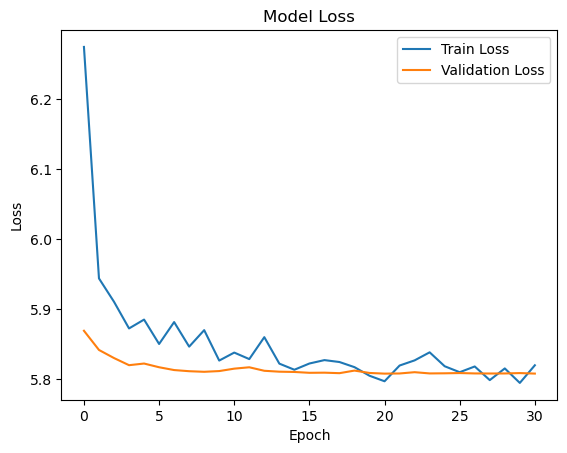

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train Loss', 'Validation Loss'])

plt.show()

In [22]:
def idx_to_word(integer,tokenizer):
    
    for word, index in tokenizer.word_index.items():
        if index==integer:
            return word
    return None


In [23]:
def predict_caption(model, image, tokenizer, max_length, features, beam_width=3):

    feature = features[image]
    in_text = "startseq"
    sequence = tokenizer.texts_to_sequences([in_text])[0]

    # Initialize beam search
    beam = [(sequence, 0.0)]

    for i in range(1, max_length):

        new_beam = []

        for seq, prob in beam:

            y_pred = model.predict([feature, pad_sequences([seq], max_length)])
            y_pred = y_pred[0]

            top_indices = np.argsort(y_pred)[-beam_width:]
            top_probabilities = y_pred[top_indices]

            for idx, prob_new in zip(top_indices, top_probabilities):

                word = idx_to_word(idx, tokenizer)

                if word is None:
                    continue

                new_seq = seq + [idx]
                new_beam.append((new_seq, prob + np.log(prob_new)))

        beam = sorted(new_beam, key=lambda x: x[1], reverse=True)[:beam_width]

    # Get the best sequence
    best_seq, _ = beam[0]

    predicted_caption = " ".join(
        [idx_to_word(idx, tokenizer) for idx in best_seq]
    )

    predicted_caption = predicted_caption.replace("startseq", "").replace("endseq", "")

    return predicted_caption

In [24]:
import os

print(os.getcwd())

print(os.listdir())

C:\Users\RAKHI ROSHAN\Downloads\Project 1
['.ipynb_checkpoints', 'model.keras', 'model.png', 'Untitled.ipynb']


In [25]:
import glob

print(glob.glob("*.jpg")[:10])

[]


In [27]:
test['image'] = test['image'].str.strip()

In [28]:
print("Total feature keys:", len(features))

print("\nFirst 5 feature keys:")
print(list(features.keys())[:5])

print("\nFirst 5 test images:")
print(test['image'].head())

Total feature keys: 0

First 5 feature keys:
[]

First 5 test images:
17775    2973269132_252bfd0160.jpg
13506     270263570_3160f360d3.jpg
4325     2053006423_6adf69ca67.jpg
37870     512101751_05a6d93e19.jpg
21321    3156406419_38fbd52007.jpg
Name: image, dtype: object


In [ ]:
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model

import numpy as np
import os

# IMAGE FOLDER PATH
IMAGE_FOLDER = r"C:\Users\RAKHI ROSHAN\Downloads\flicker 8k\Images"

# Load ResNet50 model
model = ResNet50(weights='imagenet')

# Remove last layer
model = Model(
    inputs=model.inputs,
    outputs=model.layers[-2].output
)

# Feature dictionary
features = {}

# All image names
image_names = os.listdir(IMAGE_FOLDER)

print("Total Images:", len(image_names))

# Extract features
for img_name in image_names:

    img_path = os.path.join(
        IMAGE_FOLDER,
        img_name
    )

    # Load image
    image = load_img(
        img_path,
        target_size=(224, 224)
    )

    # Convert to array
    image = img_to_array(image)

    # Reshape
    image = image.reshape(
        (1, image.shape[0], image.shape[1], image.shape[2])
    )

    # Preprocess
    image = preprocess_input(image)

    # Extract feature
    feature = model.predict(
        image,
        verbose=0
    )

    # Store feature
    features[img_name] = feature[0]

print("Feature Extraction Completed")
print("Total Features:", len(features))

Total Images: 8091


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

# Random image from features
image_name = list(features.keys())[0]

print("Image Name:", image_name)

# Folder path
IMAGE_FOLDER = r"C:\Users\RAKHI ROSHAN\Downloads\flicker 8k"

# Full image path
image_path = os.path.join(
    IMAGE_FOLDER,
    image_name
)

print("Image Path:", image_path)

# Open image
img = Image.open(image_path)

# Show image
plt.imshow(img)

plt.title(image_name)

plt.axis("off")

plt.show()

display_images_with_final_bleu(
    caption_model,
    tokenizer,
    max_length,
    features,
    test
)

In [ ]:
import matplotlib.pyplot as plt
from textwrap import wrap
import numpy as np
import os
from nltk.translate.bleu_score import sentence_bleu


def calculate_bleu_for_references(reference_captions):
    """
    Calculate BLEU scores for all pairs of reference captions.
    """
    bleu_scores = []

    for i in range(len(reference_captions)):
        for j in range(len(reference_captions)):
            if i != j:
                refs = [reference_captions[j].split()]
                candidate = reference_captions[i].split()
                bleu = sentence_bleu(refs, candidate, weights=(1.0,))
                bleu_scores.append(bleu)

    return bleu_scores


def display_images_with_final_bleu(model, tokenizer, max_length, features, test_data, num_samples=15):

    # Sample images
    sample_images = test_data.sample(num_samples)
    sample_images.reset_index(drop=True, inplace=True)

    # Figure
    plt.figure(figsize=(20, 20))

    for index, record in sample_images.iterrows():

        image_name = record['image']

        # 🔥 FIXED YOUR PATH (Flickr8k standard folder)
        image_path = os.path.join(
            r"C:\Users\RAKHI ROSHAN\Downloads\Flickr8k_Dataset\Images",
            image_name
        )

        # Load image
        image = readImage(image_path)

        # Reference captions
        reference_captions = test_data[
            test_data['image'] == image_name
        ]['caption'].apply(
            lambda x: x.replace("startseq", "").replace("endseq", "").strip()
        ).tolist()

        # Predicted caption
        predicted_caption = predict_caption(
            model, image_name, tokenizer, max_length, features
        )

        # BLEU score (predicted vs references)
        predicted_bleu = sentence_bleu(
            [caption.split() for caption in reference_captions],
            predicted_caption.split()
        )

        # BLEU for reference captions
        reference_bleu_scores = calculate_bleu_for_references(reference_captions)
        best_reference_bleu = np.max(reference_bleu_scores)

        # Final BLEU logic
        if predicted_bleu > best_reference_bleu:
            final_bleu_score = predicted_bleu
        else:
            final_bleu_score = best_reference_bleu

        # Plot
        plt.subplot(5, 5, index + 1)
        plt.imshow(image)
        plt.title(
            f"Predicted: {predicted_caption}\nFinal BLEU: {final_bleu_score:.4f}",
            fontsize=8
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# CALL FUNCTION (FIXED FEATURES DOT ERROR)
display_images_with_final_bleu(
    caption_model,
    tokenizer,
    max_length,
    features,
    test_data
)